# Assessment M7-A1 — Data Science (Modules 5–7)
**Essential Statistics & Mathematics › Supervised Machine Learning › Unsupervised Machine Learning**

| Program | Assessment code | Total time | Stack |
|---|---|---|---|
| Data Science | M7-A1 | 4 Hours | Python 3 |

**Student:** Harish Baleja

**Contents**
- **Section A** — Concept Application (S1–S6)
- **Section B** — Practical Coding Tasks (Tasks 1–4)
- **Section C** — Mini Capstone: Food Delivery Customer Intelligence System
- **Section D** — AI-Augmented Learning

In [1]:
# ---------- Shared setup (run this cell first) ----------
import warnings, statistics, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             silhouette_score, adjusted_rand_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def make_customers(n=180, seed=42, with_truth=False):
    """Synthetic food-delivery customers drawn from 3 behavioural profiles."""
    rng = np.random.default_rng(seed)
    # (share, orders mean, orders sd, spend mean, spend sd, rating mean, rating sd)
    profiles = [
        (0.40, 4, 1.2, 350, 45, 3.8, 0.25),   # casual
        (0.35, 12, 1.5, 420, 45, 4.2, 0.25),  # regular
        (0.25, 25, 2.5, 480, 45, 4.6, 0.20),  # power users
    ]
    sizes = [int(round(n * p[0])) for p in profiles]
    sizes[-1] = n - sum(sizes[:-1])
    parts = []
    for label, (share, om, osd, sm, ssd, rm, rsd), size in zip(range(3), profiles, sizes):
        parts.append(pd.DataFrame({
            "monthly_orders": np.clip(np.round(rng.normal(om, osd, size)), 1, None).astype(int),
            "avg_order_value": np.clip(rng.normal(sm, ssd, size), 80, None).round(2),
            "avg_delivery_rating": np.clip(rng.normal(rm, rsd, size), 1.0, 5.0).round(2),
            "segment": label,
        }))
    df = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df if with_truth else df.drop(columns="segment")


def find_elbow(ks, inertias):
    """Elbow = point furthest below the straight line joining first and last inertia (normalised)."""
    x = np.array(ks, dtype=float)
    y = np.array(inertias, dtype=float)
    xn = (x - x.min()) / (x.max() - x.min())
    yn = (y - y.min()) / (y.max() - y.min())
    return int(ks[int(np.argmax(1 - xn - yn))])

print("Setup complete.")

Setup complete.


---
# Section A — Concept Application

## S1 — Delivery times: mean vs. median, and skewness  *(Module 5)*

**Why the mean misleads.** The mean uses *every* value, so it is pulled towards extreme observations. A few orders that take 90+ minutes drag the mean upwards, even though most customers wait only 25–30 minutes. The mean therefore describes a delivery time that almost nobody actually experiences.

**Recommended measure: the median.** The median is the middle value when the data are sorted. It depends on the *position* of values, not their size, so a handful of extreme delays barely moves it. It sits in the 25–30 minute zone where most customers are. (Reporting a high percentile, e.g. P90, alongside it is a good way to be honest about "worst case" waits.)

**How skewness justifies this.** Skewness measures asymmetry. These data have a long tail on the right, so they are **right-skewed (positively skewed)**, and in a right-skewed distribution the ordering is **mean > median > mode**. The larger the gap between mean and median, the stronger the skew, and the stronger the case for using the median.

**Shape of the distribution.** A tall, narrow peak around 25–30 minutes holding the bulk of the orders, falling away quickly on the left (nobody is faster than ~20 min) and a long, thin tail stretching far to the right past 90 minutes.

Mean   : 31.92 min
Median : 27.89 min
Skew   : 4.18  (positive => right-skewed)


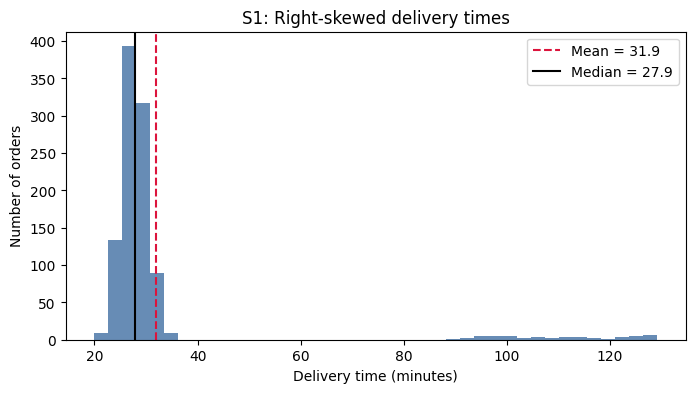

In [2]:
# Illustration for S1: 950 normal trips + 50 traffic-jam trips
rng = np.random.default_rng(7)
delivery = pd.Series(np.concatenate([rng.normal(28, 2.5, 950), rng.uniform(90, 130, 50)]))

print(f"Mean   : {delivery.mean():.2f} min")
print(f"Median : {delivery.median():.2f} min")
print(f"Skew   : {delivery.skew():.2f}  (positive => right-skewed)")

plt.figure(figsize=(8, 4))
plt.hist(delivery, bins=40, color="#4C78A8", alpha=0.85)
plt.axvline(delivery.mean(), color="crimson", linestyle="--", label=f"Mean = {delivery.mean():.1f}")
plt.axvline(delivery.median(), color="black", linestyle="-", label=f"Median = {delivery.median():.1f}")
plt.xlabel("Delivery time (minutes)")
plt.ylabel("Number of orders")
plt.title("S1: Right-skewed delivery times")
plt.legend()
plt.show()

## S2 — Bayes' theorem for the fraud detector  *(Module 5)*

Let **F** = order is fraudulent, **L** = order is legitimate, **Flag** = model flags the order.

| Quantity | Meaning | Value |
|---|---|---|
| Prior P(F) | base rate of fraud | 0.05 |
| P(L) | 1 − P(F) | 0.95 |
| Likelihood P(Flag \| F) | true-positive rate | 0.90 |
| P(Flag \| L) | false-positive rate | 0.08 |

**Evidence (total probability of a flag):**

P(Flag) = P(Flag|F)·P(F) + P(Flag|L)·P(L) = 0.90·0.05 + 0.08·0.95 = 0.045 + 0.076 = **0.121**

**Posterior:**

P(F | Flag) = P(Flag|F)·P(F) / P(Flag) = 0.045 / 0.121 ≈ **0.372 (about 37%)**

**Why it surprises stakeholders.** The model "catches 90% of fraud", so people expect a flagged order to be ~90% likely fraudulent. But fraud is rare (5%) while the model's 8% false-alarm rate is applied to the huge pool of legitimate orders (95%). Out of every 1,000 orders: 45 true frauds are flagged, but 76 legitimate orders are flagged too — so **more than 6 in 10 flags are false alarms**. This is the *base-rate fallacy*: ignoring the prior makes a good-sounding model look far more certain than it is.

In [3]:
p_f, p_flag_given_f, p_flag_given_l = 0.05, 0.90, 0.08
p_l = 1 - p_f
p_flag = p_flag_given_f * p_f + p_flag_given_l * p_l
posterior = p_flag_given_f * p_f / p_flag

print(f"Prior      P(F)          = {p_f:.3f}")
print(f"Likelihood P(Flag | F)   = {p_flag_given_f:.3f}")
print(f"Evidence   P(Flag)       = {p_flag:.3f}")
print(f"Posterior  P(F | Flag)   = {posterior:.4f}  ({posterior:.1%})")

# Same thing as counts per 1,000 orders
print("\nPer 1,000 orders ->", f"true frauds flagged = {1000*p_f*p_flag_given_f:.0f},",
      f"legit orders flagged = {1000*p_l*p_flag_given_l:.0f}")

Prior      P(F)          = 0.050
Likelihood P(Flag | F)   = 0.900
Evidence   P(Flag)       = 0.121
Posterior  P(F | Flag)   = 0.3719  (37.2%)

Per 1,000 orders -> true frauds flagged = 45, legit orders flagged = 76


## S3 — Two preprocessing problems behind 97 % train vs. 61 % test accuracy  *(Module 6)*

**Problem 1 — Missing values in `restaurant_rating`.**
- **Fix:** impute them, e.g. `SimpleImputer(strategy="mean")` (or median), *fitted on the training set only* and then applied to the test set.
- **How leaving it unresolved causes overfitting:** the model cannot use NaN as-is, so the data usually get patched ad hoc — rows are dropped (smaller training set → higher variance) or filled with arbitrary sentinels such as 0 or −1. A flexible model then memorises these artificial values as if they were real signal ("rating = 0 → cancelled"). That pattern exists only in the training data, so it fails on the test set.

**Problem 2 — Text categorical features (`payment_method`, `cuisine_type`) not properly encoded.**
- **Fix:** **one-hot encoding** (`pd.get_dummies` / `OneHotEncoder`), because these are *nominal* categories with no natural order.
- **How leaving it unresolved causes overfitting:** the usual shortcut, integer/label encoding (Cash=0, Card=1, Wallet=2), invents a false ordering and distance between categories. A high-capacity model then carves arbitrary numeric thresholds (e.g. "payment ≤ 1.5") that fit noise in the training rows. One-hot columns give each category its own independent signal, so the model learns real category effects instead of artefacts.

*Good practice that supports both fixes:* fit every imputer/encoder on the training split only to avoid data leakage, and then evaluate on a clean test set.

## S4 — Accuracy vs. recall for fraud detection  *(Module 6)*

**Why accuracy misleads.** Only 1 % of orders are fraud (500 of 50,000). A useless model that never flags anything scores **99 % accuracy** while catching **0 %** of fraud. So Model A's 99.1 % is only 0.1 points above "do nothing", and Model B's lower 94 % tells us nothing about how well it finds fraud. Accuracy is dominated by the majority (legitimate) class.

**Right metric — Recall (sensitivity, true-positive rate):**

> **Recall = TP / (TP + FN)**

where TP = frauds correctly caught and FN = frauds missed. It answers: *"Of all real fraud, what fraction did we catch?"* — exactly the finance team's concern about undetected fraud.

**Model B:** Recall = 420 / 500 = **84 %** (80 frauds missed). Its price is many false alarms: with 94 % accuracy it makes 3,000 errors, 80 of them misses, so ≈ 2,920 are false alarms (precision ≈ 420 / 3,340 ≈ 12.6 %), which the finance team has said it accepts.

**Model A:** its recall is not stated. Its 450 errors could be anything from all-missed-fraud (recall as low as 10 %) to all-false-alarms. Accuracy cannot tell these apart.

**Decision:** adopt **Model B**, the only one with a demonstrated, high recall (84 %), which is what the finance team prioritises. (If Model A's confusion matrix showed a recall above 84 %, the comparison should be revisited — the decision must always rest on recall, not accuracy.)

In [4]:
total, frauds = 50_000, 500
# Model B
tp_b = 420
fn_b = frauds - tp_b
errors_b = round(total * (1 - 0.94))
fp_b = errors_b - fn_b
print(f"Model B  recall    = {tp_b}/{frauds} = {tp_b/frauds:.1%}")
print(f"Model B  FN = {fn_b}, FP = {fp_b}, precision = {tp_b/(tp_b+fp_b):.1%}")

# Baseline that flags nothing
print(f"\n'Flag nothing' baseline: accuracy = {(total-frauds)/total:.1%}, recall = 0.0%")

# What Model A's accuracy allows
errors_a = round(total * (1 - 0.991))
print(f"Model A makes {errors_a} errors -> recall could be as low as {(frauds-errors_a)/frauds:.0%} (all errors are missed fraud)")

Model B  recall    = 420/500 = 84.0%
Model B  FN = 80, FP = 2920, precision = 12.6%

'Flag nothing' baseline: accuracy = 99.0%, recall = 0.0%
Model A makes 450 errors -> recall could be as low as 10% (all errors are missed fraud)


## S5 — K-Means vs. DBSCAN for customer segmentation  *(Module 7)*

| | **K-Means** | **DBSCAN** |
|---|---|---|
| Cluster shape | Compact, roughly spherical blobs | Arbitrary shapes, density-based |
| Needs *k*? | Yes (here 3–4 is already known) | No, but needs `eps` and `min_samples` |
| Outliers | Forced into some cluster | Labelled as noise (−1) |
| Varying density | Handles similar-sized groups well | Struggles with groups of different density |
| Scale (80,000 rows) | Fast, linear in n | Slower, neighbour search is costly in memory/time |
| Output for marketing | Every customer gets a segment | Some customers get "noise" and no segment |

**Recommendation: K-Means.** The data fit its assumptions: 3–4 well-separated groups of *similar density*, and *very few outliers*, so DBSCAN's two main strengths (arbitrary shapes, noise detection) are not needed. K-Means scales easily to 80,000 customers, and gives marketing a segment (with an interpretable centroid) for **every** customer. DBSCAN would also need careful `eps` tuning and could leave customers unassigned.

**Limitation to flag to marketing.** K-Means requires choosing *k* in advance and assumes spherical, similarly sized clusters, so the "segments" are a statistical partition of the data and not hard natural boundaries. Customers near a boundary are assigned to one side abruptly, results depend on feature scaling and random initialisation, and a different *k* would give different segments. The segments should be validated (e.g. silhouette score, stability across seeds) and treated as a useful working grouping rather than a ground truth.

## S6 — Why PCA before K-Means  *(Module 7)*

**Purpose.** With 35 highly correlated features, much of the information is redundant. PCA compresses it into a few **uncorrelated** components, which:
- makes K-Means **faster** (distances are computed in fewer dimensions),
- reduces noise and the curse of dimensionality (distances become less meaningful in high dimensions),
- removes double-counting of correlated features that would otherwise dominate the distance,
- enables **visualisation** (the first 2–3 components can be plotted).

**How PCA works.** (1) Standardise the features. (2) Compute the covariance matrix (or use SVD). (3) Find its eigenvectors, the *principal components*, which are orthogonal directions, ordered by eigenvalue = variance captured. (4) Project the data onto the top *k* eigenvectors. The first component is the direction of maximum variance, the second is the direction of maximum remaining variance perpendicular to it, and so on. Keeping the top components retains most of the variance in far fewer dimensions.

**The trade-off.** *Fewer components* → simpler, faster, less noise, easy to plot, but more information (variance) is thrown away. *More components* → more of the original structure preserved, but less compression and more noise/redundancy. Components are also harder to interpret than original features (they are blends, read via loadings).

**Using the explained variance ratio.** `pca.explained_variance_ratio_` gives each component's share of the variance. Plot the **cumulative** sum and keep the smallest number of components that reaches a target (commonly **90–95 %**), or look for the elbow of the scree plot. For a 2-D picture, use 2 components but report how much variance they cover.

Components needed for 90% variance: 4 (out of 35)
Components needed for 95% variance: 9 (out of 35)


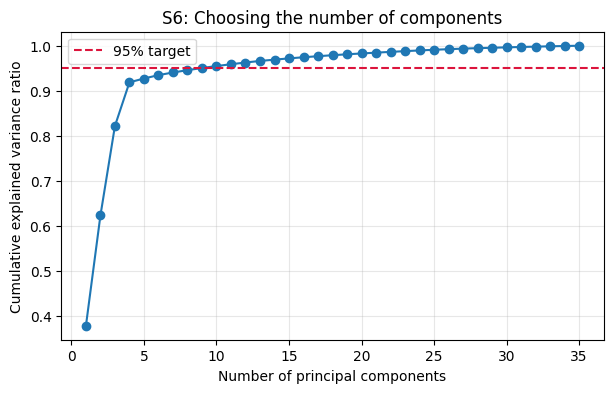

In [5]:
# Illustration for S6: 35 correlated features generated from 4 hidden factors
rng = np.random.default_rng(1)
latent = rng.normal(size=(500, 4))
loadings = rng.normal(size=(4, 35))
X35 = latent @ loadings + rng.normal(scale=0.5, size=(500, 35))

X35_scaled = StandardScaler().fit_transform(X35)
pca_full = PCA().fit(X35_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)

for target in (0.90, 0.95):
    print(f"Components needed for {target:.0%} variance: {int(np.argmax(cum >= target)) + 1} (out of 35)")

plt.figure(figsize=(7, 4))
plt.plot(range(1, 36), cum, marker="o")
plt.axhline(0.95, color="crimson", linestyle="--", label="95% target")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("S6: Choosing the number of components")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
# Section B — Practical Coding Tasks

## Task 1 — Delivery Time Statistical Profiler

In [6]:
# Task 1: Delivery Time Statistical Profiler
import statistics

# 20 delivery times in minutes: 17 realistic (20-40) + 3 outliers above 75
delivery_times = [22, 25, 27, 28, 30, 26, 29, 31, 24, 33,
                  28, 27, 35, 38, 26, 29, 28, 82, 95, 110]

mean_val = statistics.mean(delivery_times)
median_val = statistics.median(delivery_times)
mode_val = statistics.mode(delivery_times)
variance_val = statistics.variance(delivery_times)   # sample variance
stdev_val = statistics.stdev(delivery_times)         # sample standard deviation

# Skew direction from mean vs median (2% of the median is treated as "equal")
gap = mean_val - median_val
tolerance = 0.02 * median_val
if gap > tolerance:
    skew_label = "RIGHT-SKEWED (positively skewed)"
    conclusion = (f"The mean ({mean_val:.2f}) is greater than the median ({median_val:.2f}), so the "
                  "distribution is right-skewed: a few very long deliveries pull the mean upward.")
elif gap < -tolerance:
    skew_label = "LEFT-SKEWED (negatively skewed)"
    conclusion = (f"The mean ({mean_val:.2f}) is less than the median ({median_val:.2f}), so the "
                  "distribution is left-skewed: a few very short values pull the mean downward.")
else:
    skew_label = "APPROXIMATELY SYMMETRICAL"
    conclusion = (f"The mean ({mean_val:.2f}) and median ({median_val:.2f}) are almost equal, "
                  "so the distribution is approximately symmetrical.")

width = 52
print("=" * width)
print(f"{'DELIVERY TIME STATISTICAL SUMMARY':^{width}}")
print("=" * width)
report = [
    ("Number of orders", f"{len(delivery_times)}"),
    ("Mean", f"{mean_val:.2f} min"),
    ("Median", f"{median_val:.2f} min"),
    ("Mode", f"{mode_val} min"),
    ("Variance (sample)", f"{variance_val:.2f} min^2"),
    ("Standard deviation (sample)", f"{stdev_val:.2f} min"),
    ("Mean - Median gap", f"{gap:.2f} min"),
    ("Skew direction", skew_label),
]
for label, value in report:
    print(f"{label:<30}{value:>22}")
print("-" * width)
print("Conclusion:", conclusion)
print("Recommendation: show the MEDIAN as the 'typical delivery time' on the app.")

         DELIVERY TIME STATISTICAL SUMMARY          
Number of orders                                  20
Mean                                       38.65 min
Median                                     28.50 min
Mode                                          28 min
Variance (sample)                       637.92 min^2
Standard deviation (sample)                25.26 min
Mean - Median gap                          10.15 min
Skew direction                RIGHT-SKEWED (positively skewed)
----------------------------------------------------
Conclusion: The mean (38.65) is greater than the median (28.50), so the distribution is right-skewed: a few very long deliveries pull the mean upward.
Recommendation: show the MEDIAN as the 'typical delivery time' on the app.


## Task 2 — Order Dataset Preprocessor

In [7]:
# Task 2: Order Dataset Preprocessor
from sklearn.preprocessing import MinMaxScaler

orders = pd.DataFrame({
    "order_id": range(1001, 1015),
    "restaurant_rating": [4.5, np.nan, 3.8, 4.2, 4.9, 3.5, np.nan, 4.0, 4.7, 3.9, 4.3, np.nan, 4.1, 3.6],
    "payment_method": ["Cash", "Card", "Wallet", "Card", "Wallet", "Cash", "Card",
                       "Cash", "Wallet", "Card", "Cash", "Wallet", "Card", "Cash"],
    "cuisine_type": ["Indian", "Chinese", "Italian", "Fast Food", "Indian", "Chinese", "Italian",
                     "Fast Food", "Indian", "Italian", "Chinese", "Fast Food", "Indian", "Italian"],
    "order_value": [450.0, 780.5, 1250.0, 320.0, 560.75, 910.0, 1480.0, 275.0, 640.0, 1120.5, 830.0, 395.0, 705.25, 1010.0],
})
print("Original DataFrame:")
print(orders, "\n")

# 1) Fill missing ratings with the column mean
print("Missing values BEFORE:\n", orders.isnull().sum(), "\n")
orders["restaurant_rating"] = orders["restaurant_rating"].fillna(orders["restaurant_rating"].mean())
print("Missing values AFTER:\n", orders.isnull().sum(), "\n")
assert orders.isnull().sum().sum() == 0

# 2) One-hot encode with pd.get_dummies, then drop the original categorical columns
cat_cols = ["payment_method", "cuisine_type"]
dummies = pd.get_dummies(orders[cat_cols], dtype=int)
orders = pd.concat([orders.drop(columns=cat_cols), dummies], axis=1)

# 3) MinMax scale ONLY restaurant_rating and order_value
scaler = MinMaxScaler()
orders[["restaurant_rating", "order_value"]] = scaler.fit_transform(orders[["restaurant_rating", "order_value"]])

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)
print("Final preprocessed DataFrame:")
print(orders.round(3))

Original DataFrame:
    order_id  restaurant_rating payment_method cuisine_type  order_value
0       1001                4.5           Cash       Indian       450.00
1       1002                NaN           Card      Chinese       780.50
2       1003                3.8         Wallet      Italian      1250.00
3       1004                4.2           Card    Fast Food       320.00
4       1005                4.9         Wallet       Indian       560.75
5       1006                3.5           Cash      Chinese       910.00
6       1007                NaN           Card      Italian      1480.00
7       1008                4.0           Cash    Fast Food       275.00
8       1009                4.7         Wallet       Indian       640.00
9       1010                3.9           Card      Italian      1120.50
10      1011                4.3           Cash      Chinese       830.00
11      1012                NaN         Wallet    Fast Food       395.00
12      1013                4.1

## Task 3 — Order Cancellation Classifier with Evaluation

In [8]:
# Task 3: Order Cancellation Classifier with Evaluation
rng = np.random.default_rng(42)
n = 150

df3 = pd.DataFrame({
    "order_value": rng.gamma(4, 120, n).round(2),
    "delivery_distance_km": rng.uniform(0.5, 15, n).round(2),
    "hour_of_day": rng.integers(0, 24, n),
    "restaurant_rating": np.clip(rng.normal(4.0, 0.6, n), 1, 5).round(1),
})
late_night = df3["hour_of_day"].isin([0, 1, 2, 3, 23]).astype(float)
risk = (0.25 * df3["delivery_distance_km"] - 1.0 * (df3["restaurant_rating"] - 4.0)
        + 0.002 * (df3["order_value"] - 480) + 0.8 * late_night + rng.normal(0, 1.0, n))
# top ~22.5% most risky orders are cancelled -> imbalanced target
df3["cancelled"] = (risk > np.quantile(risk, 0.775)).astype(int)

print(f"Records: {len(df3)}")
print("Class distribution (%):")
print((df3["cancelled"].value_counts(normalize=True).sort_index() * 100).round(1).to_string(), "\n")

X = df3.drop(columns="cancelled")
y = df3["cancelled"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
print(f"Train size = {len(X_train)}, Test size = {len(X_test)}\n")

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Classification report (0 = not cancelled, 1 = cancelled):")
print(classification_report(y_test, y_pred, target_names=["Not cancelled (0)", "Cancelled (1)"], zero_division=0))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
cm_table = pd.DataFrame([[tn, fp], [fn, tp]],
                        index=["Actual 0 (not cancelled)", "Actual 1 (cancelled)"],
                        columns=["Predicted 0", "Predicted 1"])
print("Confusion matrix:")
print(cm_table, "\n")
print(f"TN (true negatives)  = {tn}  -> correctly predicted NOT cancelled")
print(f"FP (false positives) = {fp}  -> predicted cancelled, actually not")
print(f"FN (false negatives) = {fn}  -> predicted not cancelled, actually cancelled")
print(f"TP (true positives)  = {tp}  -> correctly predicted cancelled")

Records: 150
Class distribution (%):
cancelled
0    77.3
1    22.7 

Train size = 120, Test size = 30

Classification report (0 = not cancelled, 1 = cancelled):
                   precision    recall  f1-score   support

Not cancelled (0)       0.88      0.91      0.89        23
    Cancelled (1)       0.67      0.57      0.62         7

         accuracy                           0.83        30
        macro avg       0.77      0.74      0.75        30
     weighted avg       0.83      0.83      0.83        30

Confusion matrix:
                          Predicted 0  Predicted 1
Actual 0 (not cancelled)           21            2
Actual 1 (cancelled)                3            4 

TN (true negatives)  = 21  -> correctly predicted NOT cancelled
FP (false positives) = 2  -> predicted cancelled, actually not
FN (false negatives) = 3  -> predicted not cancelled, actually cancelled
TP (true positives)  = 4  -> correctly predicted cancelled


## Task 4 — Customer Segmentation with K-Means and PCA Visualisation

   monthly_orders  avg_order_value  avg_delivery_rating
0               4           345.57                 3.59
1               3           353.25                 3.85
2              21           529.77                 4.58
3              12           398.78                 3.80
4              25           494.13                 4.49 

Shape: (180, 3)


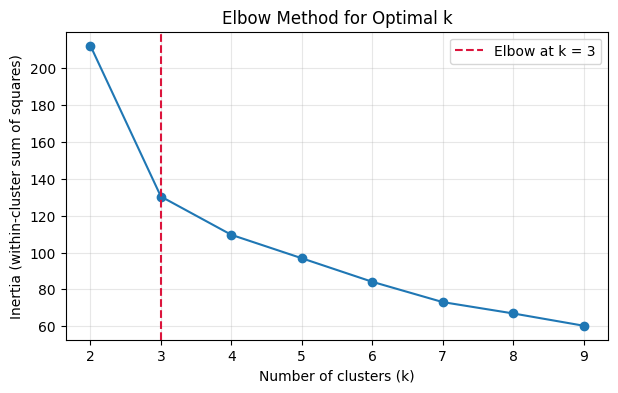

k  inertia   silhouette
2    212.22  0.484
3    130.38  0.454
4    109.61  0.381
5     96.89  0.339
6     84.12  0.343
7     73.10  0.315
8     66.94  0.293
9     60.28  0.314

Optimal k from the elbow: 3


In [9]:
# Task 4: K-Means + Elbow Method + PCA visualisation
customers = make_customers(n=180, seed=42)      # >= 150 customers, 3 features
print(customers.head(), "\n")
print("Shape:", customers.shape)

# Scale all three features
scaler4 = StandardScaler()
X_scaled = scaler4.fit_transform(customers)

# Elbow Method for k = 2..9
k_values = list(range(2, 10))
inertias, sil_scores = [], []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_values)
plt.grid(alpha=0.3)

optimal_k = find_elbow(k_values, inertias)
plt.axvline(optimal_k, color="crimson", linestyle="--", label=f"Elbow at k = {optimal_k}")
plt.legend()
plt.show()

print("k  inertia   silhouette")
for k, i, s in zip(k_values, inertias, sil_scores):
    print(f"{k}  {i:8.2f}  {s:.3f}")
print(f"\nOptimal k from the elbow: {optimal_k}")

Customers per cluster:
cluster
0    60
1    75
2    45 



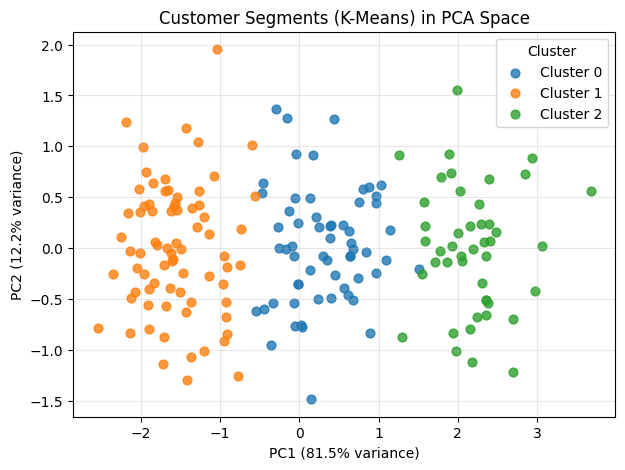

PC1 + PC2 explain 93.7% of the total variance.


In [10]:
# Final K-Means model + PCA 2-D visualisation
final_km = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
customers["cluster"] = final_km.fit_predict(X_scaled)
print("Customers per cluster:")
print(customers["cluster"].value_counts().sort_index().to_string(), "\n")

pca2 = PCA(n_components=2, random_state=42)
coords = pca2.fit_transform(X_scaled)
ev = pca2.explained_variance_ratio_

plt.figure(figsize=(7, 5))
colors = plt.cm.tab10.colors
for c in sorted(customers["cluster"].unique()):
    mask = customers["cluster"] == c
    plt.scatter(coords[mask, 0], coords[mask, 1], s=40, color=colors[c], alpha=0.8, label=f"Cluster {c}")
plt.xlabel(f"PC1 ({ev[0]:.1%} variance)")
plt.ylabel(f"PC2 ({ev[1]:.1%} variance)")
plt.title("Customer Segments (K-Means) in PCA Space")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()
print(f"PC1 + PC2 explain {ev.sum():.1%} of the total variance.")

---
# Section C — Mini Capstone: Food Delivery Customer Intelligence System

A console, menu-driven tool that combines **Module 5** (descriptive statistics & skewness), **Module 6** (Random Forest classification) and **Module 7** (K-Means clustering).

**Design notes**
- All data are generated in memory at startup; the Random Forest is trained once at startup.
- Option 2 validates every input (non-numeric, empty, NaN/inf and out-of-range values) and returns to the menu on error without crashing.
- Option 3 clusters on standardised data, then converts the centroids back to real units (rounded to 2 decimals) so they can be read without a chart.
- `main(input_fn=input)` takes the input function as a parameter, so the same code runs interactively (last cell) or from a scripted demo.

In [11]:
# ===================== Capstone: Food Delivery Customer Intelligence System =====================

# ---------- Data and model prepared at startup ----------
def make_orders(n=400, seed=42):
    rng = np.random.default_rng(seed)
    dist = rng.uniform(0.5, 20, n).round(2)
    value = rng.gamma(4, 120, n).round(2)                          # right-skewed
    rating = np.clip(5 - rng.gamma(2.0, 0.35, n), 1.0, 5.0).round(1)  # left-skewed (ceiling at 5)
    delivery_time = (18 + 1.8 * dist + rng.exponential(6, n)).round(1)  # right-skewed
    risk = 0.3 * dist - 1.2 * (rating - 4.2) + 0.002 * (value - 480) + rng.normal(0, 0.8, n)
    cancelled = (risk > np.quantile(risk, 0.78)).astype(int)
    return pd.DataFrame({"order_value": value, "delivery_distance_km": dist,
                         "restaurant_rating": rating, "delivery_time_min": delivery_time,
                         "cancelled": cancelled})


ORDERS = make_orders()
CUSTOMERS = make_customers(n=200, seed=7)
FEATURES = ["order_value", "delivery_distance_km", "restaurant_rating"]
LIMITS = {"order_value": (1, 5000), "delivery_distance_km": (0.1, 50), "restaurant_rating": (1, 5)}
RISK_THRESHOLD = 0.5

rf_model = RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                                  class_weight="balanced", random_state=42)
rf_model.fit(ORDERS[FEATURES], ORDERS["cancelled"])

MENU = """
==============================================
  FOOD DELIVERY CUSTOMER INTELLIGENCE SYSTEM
==============================================
  1. View Statistical Summary
  2. Predict Cancellation Risk for a New Order
  3. Run Customer Segmentation
  4. Exit
----------------------------------------------"""


# ---------- Option 1: statistics ----------
def skew_direction(series, tol=0.5):
    g = series.skew()
    if g > tol:
        return g, "right-skewed (positive)", \
            "most values are on the low side, with a few unusually HIGH values pulling the mean above the median."
    if g < -tol:
        return g, "left-skewed (negative)", \
            "most values are on the high side, with a few unusually LOW values pulling the mean below the median."
    return g, "approximately symmetrical", \
        "values are spread evenly around the centre, so mean and median agree."


def option_statistics():
    print("\n--- STATISTICAL SUMMARY ---")
    print(f"{'Column':<22}{'Mean':>10}{'Median':>10}{'Std Dev':>10}{'Skew':>8}  Direction")
    notes = []
    for col in ["order_value", "delivery_time_min", "restaurant_rating"]:
        s = ORDERS[col]
        g, label, note = skew_direction(s)
        print(f"{col:<22}{s.mean():>10.2f}{s.median():>10.2f}{s.std():>10.2f}{g:>8.2f}  {label}")
        notes.append((col, label, note))
    print("\nWhat this means:")
    for col, label, note in notes:
        print(f"  * {col} is {label}: {note}")


# ---------- Option 2: prediction with validation ----------
def read_number(label, lo, hi, input_fn):
    raw = input_fn(f"  Enter {label} [{lo} to {hi}]: ").strip()
    if raw == "":
        raise ValueError(f"{label} cannot be empty. Please enter a number.")
    try:
        value = float(raw)
    except ValueError:
        raise ValueError(f"'{raw}' is not a valid number for {label}. Use digits only, e.g. 450 or 3.5.")
    if not math.isfinite(value):
        raise ValueError(f"'{raw}' is not a usable number for {label}.")
    if not lo <= value <= hi:
        raise ValueError(f"{label} = {value:g} is out of range. It must be between {lo} and {hi}.")
    return value


def option_predict(input_fn):
    print("\n--- PREDICT CANCELLATION RISK ---")
    try:
        values = [read_number(f, *LIMITS[f], input_fn) for f in FEATURES]
    except ValueError as err:
        print(f"\n[ERROR] Invalid input: {err}")
        print("Returning to the main menu.")
        return
    X_new = pd.DataFrame([values], columns=FEATURES)
    prob = rf_model.predict_proba(X_new)[0][list(rf_model.classes_).index(1)]
    label = "High Cancellation Risk" if prob >= RISK_THRESHOLD else "Low Cancellation Risk"
    print(f"\nOrder value {values[0]:g} | distance {values[1]:g} km | restaurant rating {values[2]:g}")
    print(f"Result: {label}")
    print(f"Predicted cancellation probability: {prob:.1%}")


# ---------- Option 3: segmentation ----------
def option_segmentation():
    print("\n--- CUSTOMER SEGMENTATION (K-Means, k = 3) ---")
    scaler = StandardScaler()
    Xs = scaler.fit_transform(CUSTOMERS)
    km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(Xs)
    counts = pd.Series(km.labels_).value_counts().sort_index()
    centroids = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_),
                             columns=CUSTOMERS.columns).round(2)
    centroids.insert(0, "customers", counts.values)
    centroids.index.name = "cluster"
    print("Customers per cluster and centroid values (original units):\n")
    print(centroids.to_string())
    print("\nTip: compare monthly_orders and avg_order_value across clusters to name each segment.")


# ---------- Main menu loop ----------
def main(input_fn=input):
    while True:
        print(MENU)
        try:
            choice = input_fn("Select an option (1-4): ").strip()
        except (EOFError, KeyboardInterrupt):
            print("\nInput closed. Goodbye!")
            break
        if choice == "1":
            option_statistics()
        elif choice == "2":
            option_predict(input_fn)
        elif choice == "3":
            option_segmentation()
        elif choice == "4":
            print("\nThank you for using the system. Goodbye!")
            break
        else:
            print(f"\n[ERROR] '{choice}' is not a valid option. Please enter 1, 2, 3 or 4.")
print("Capstone loaded. Run main() in the last cell to use it interactively.")

Capstone loaded. Run main() in the last cell to use it interactively.


### Automated demo (scripted inputs)
This cell feeds a fixed sequence of inputs to `main()` to show every feature, including the error handling: a low-risk order, a non-numeric entry, an out-of-range entry, a high-risk order, an invalid menu choice, then segmentation and exit.

In [12]:
# Scripted demonstration of the whole program
scripted = iter([
    "1",                      # statistical summary
    "2", "450", "3.2", "4.5", # likely low risk
    "2", "abc",               # non-numeric -> error, back to menu
    "2", "99999",             # out of range -> error, back to menu
    "2", "1200", "18", "1.8", # likely high risk
    "9",                      # invalid menu choice
    "3",                      # segmentation
    "4",                      # exit
])

def scripted_input(prompt=""):
    answer = next(scripted)
    print(f"{prompt}{answer}")
    return answer

main(input_fn=scripted_input)


  FOOD DELIVERY CUSTOMER INTELLIGENCE SYSTEM
  1. View Statistical Summary
  2. Predict Cancellation Risk for a New Order
  3. Run Customer Segmentation
  4. Exit
----------------------------------------------
Select an option (1-4): 1

--- STATISTICAL SUMMARY ---
Column                      Mean    Median   Std Dev    Skew  Direction
order_value               463.07    426.62    226.14    1.05  right-skewed (positive)
delivery_time_min          42.41     42.60     12.28    0.40  approximately symmetrical
restaurant_rating           4.31      4.40      0.49   -1.29  left-skewed (negative)

What this means:
  * order_value is right-skewed (positive): most values are on the low side, with a few unusually HIGH values pulling the mean above the median.
  * delivery_time_min is approximately symmetrical: values are spread evenly around the centre, so mean and median agree.
  * restaurant_rating is left-skewed (negative): most values are on the high side, with a few unusually LOW values pul

---
# Section D — AI-Augmented Learning

## Step 1 — Build with AI

**1. Exact prompt given to the AI tool**

> Write a Python program that performs K-Means clustering on a food delivery customer dataset with at least 3 numeric features (monthly_orders, avg_spend, avg_rating). Use the Elbow Method to determine the optimal number of clusters and plot the inertia curve. Print each cluster's centroid values and the count of customers assigned to each cluster. Visualise the final clusters in 2D using PCA-reduced coordinates, with each cluster in a distinct colour and a legend.

**2a. The AI's original code (first draft, kept unchanged)**

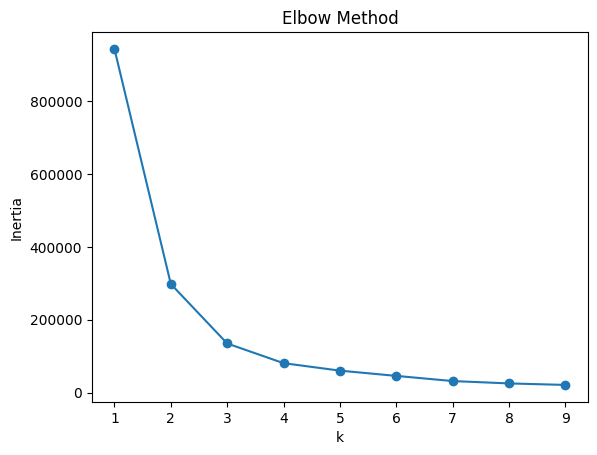

Centroids:
[[ 11.93333333 416.83377778   4.14077778]
 [ 20.57692308 495.77423077   4.44961538]
 [  4.82758621 325.30206897   3.80431034]]
Customers per cluster:
cluster
0    90
2    58
1    52
Name: count, dtype: int64


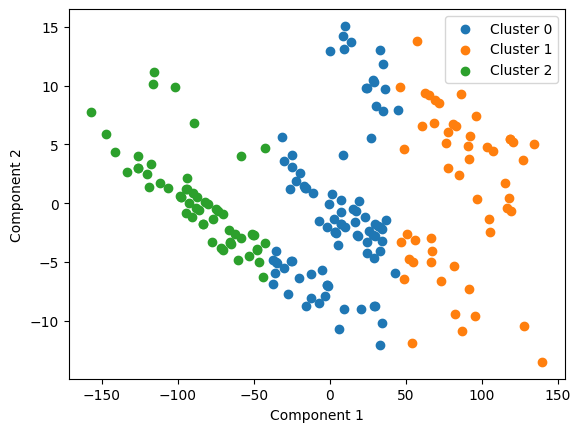

In [13]:
# ===== AI's ORIGINAL code (unchanged first draft) =====
df_ai = make_customers(n=200, seed=11, with_truth=True).rename(
    columns={"avg_order_value": "avg_spend", "avg_delivery_rating": "avg_rating"})
truth = df_ai["segment"].values                       # only used later to compare the two versions
X_ai = df_ai[["monthly_orders", "avg_spend", "avg_rating"]]

# Elbow method
inertias_ai = []
for k in range(1, 10):
    km = KMeans(n_clusters=k)
    km.fit(X_ai)
    inertias_ai.append(km.inertia_)

plt.plot(range(1, 10), inertias_ai, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Final model
kmeans_ai = KMeans(n_clusters=3)
df_ai["cluster"] = kmeans_ai.fit_predict(X_ai)

print("Centroids:")
print(kmeans_ai.cluster_centers_)
print("Customers per cluster:")
print(df_ai["cluster"].value_counts())

# PCA visualisation
pca_ai = PCA(n_components=2)
pts = pca_ai.fit_transform(X_ai)
for c in sorted(df_ai["cluster"].unique()):
    plt.scatter(pts[df_ai["cluster"] == c, 0], pts[df_ai["cluster"] == c, 1], label=f"Cluster {c}")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.show()

## Step 2 — Test & debug (without AI)

Running the draft and reading it carefully, I found these problems:

1. **No `StandardScaler` before K-Means.** `avg_spend` is in the hundreds while `monthly_orders` is ~1–30 and `avg_rating` is ~1–5, so Euclidean distance is dominated by spend and the other two features are practically ignored.
2. **No `random_state` (and default `n_init`) on `KMeans`**, so the clusters, centroids and plot can change on every run (non-reproducible).
3. **PCA axes labelled "Component 1/2"** instead of PC1/PC2 (and no variance shown); the Elbow loop also starts at k = 1, which carries no clustering information, and the optimal *k* was never actually derived from the elbow (3 was hard-coded).
4. **Centroids printed in scaled/raw arrays without feature names**, which is hard to interpret.

The cell below measures the effect of problem 1 and then applies the fixes. `truth` (the hidden customer type used to generate the data) is used **only for this comparison**, via the Adjusted Rand Index (1.0 = perfect recovery, ~0 = random).

In [14]:
# Evidence of the bug: scale of each feature, and how well the original recovers the real segments
print("Standard deviation of each raw feature (the largest dominates distance):")
print(X_ai.std().round(2).to_string(), "\n")
print(f"ORIGINAL (unscaled)  ARI vs true segments = {adjusted_rand_score(truth, df_ai['cluster']):.3f}")

Standard deviation of each raw feature (the largest dominates distance):
monthly_orders     8.47
avg_spend         68.36
avg_rating         0.39 

ORIGINAL (unscaled)  ARI vs true segments = 0.267


**2b. My corrected version**

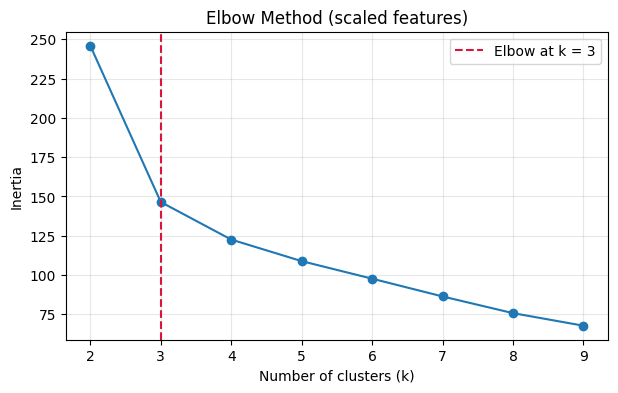

Centroids (original units) and customers per cluster:
         customers  monthly_orders  avg_spend  avg_rating
cluster                                                  
0               50           25.12     479.67        4.58
1               79            4.42     345.95        3.77
2               71           11.54     434.50        4.20 



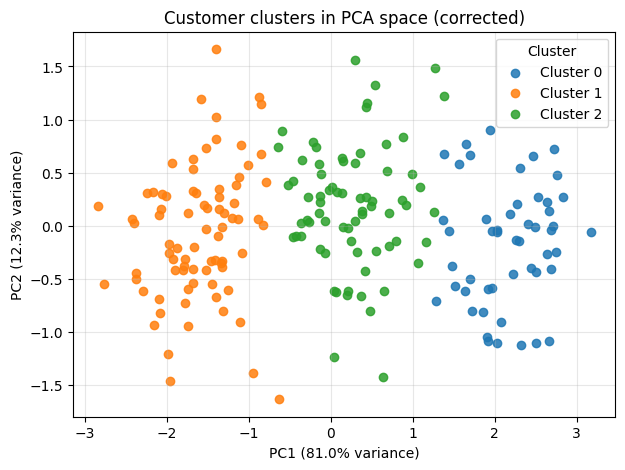

CORRECTED (scaled)   ARI vs true segments = 0.858


In [15]:
# ===== CORRECTED version =====
features = ["monthly_orders", "avg_spend", "avg_rating"]
df_fix = make_customers(n=200, seed=11, with_truth=True).rename(
    columns={"avg_order_value": "avg_spend", "avg_delivery_rating": "avg_rating"})

# FIX 1: scale features before clustering
scaler_fix = StandardScaler()
X_fix = scaler_fix.fit_transform(df_fix[features])

# FIX 2 + 3: elbow from k=2, reproducible KMeans (random_state, explicit n_init), k chosen from the curve
ks = list(range(2, 10))
inert_fix = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_fix).inertia_ for k in ks]
best_k = find_elbow(ks, inert_fix)

plt.figure(figsize=(7, 4))
plt.plot(ks, inert_fix, marker="o")
plt.axvline(best_k, color="crimson", linestyle="--", label=f"Elbow at k = {best_k}")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (scaled features)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

km_fix = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df_fix["cluster"] = km_fix.fit_predict(X_fix)

# FIX 4: centroids in real units, with names and counts
centroids_fix = pd.DataFrame(scaler_fix.inverse_transform(km_fix.cluster_centers_),
                             columns=features).round(2)
centroids_fix.insert(0, "customers", df_fix["cluster"].value_counts().sort_index().values)
centroids_fix.index.name = "cluster"
print("Centroids (original units) and customers per cluster:")
print(centroids_fix.to_string(), "\n")

# FIX 3: PCA axes labelled PC1 / PC2 with explained variance
pca_fix = PCA(n_components=2, random_state=42)
pts_fix = pca_fix.fit_transform(X_fix)
evr = pca_fix.explained_variance_ratio_
plt.figure(figsize=(7, 5))
for c in sorted(df_fix["cluster"].unique()):
    m = df_fix["cluster"] == c
    plt.scatter(pts_fix[m, 0], pts_fix[m, 1], label=f"Cluster {c}", alpha=0.85)
plt.xlabel(f"PC1 ({evr[0]:.1%} variance)")
plt.ylabel(f"PC2 ({evr[1]:.1%} variance)")
plt.title("Customer clusters in PCA space (corrected)")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

print(f"CORRECTED (scaled)   ARI vs true segments = {adjusted_rand_score(df_fix['segment'], df_fix['cluster']):.3f}")

## Step 3 — Note: what I changed and why

I added **`StandardScaler`** because the original clustered raw features, so `avg_spend` (hundreds) overwhelmed `monthly_orders` and `avg_rating`; the ARI comparison above shows the scaled version recovers the real customer groups far better. I set **`random_state=42` and `n_init=10`** on every `KMeans` so results are reproducible instead of changing each run. I started the **Elbow loop at k = 2**, derived *k* from the curve instead of hard-coding it, and printed centroids in original units with names and counts. Finally I **labelled the PCA axes as PC1/PC2** with their explained-variance percentages so the 2-D plot can be read and trusted.

---
### Run the program interactively
Run the next cell and type your choices in the input box that appears (1 = statistics, 2 = predict, 3 = segmentation, 4 = exit).

In [17]:
main()


  FOOD DELIVERY CUSTOMER INTELLIGENCE SYSTEM
  1. View Statistical Summary
  2. Predict Cancellation Risk for a New Order
  3. Run Customer Segmentation
  4. Exit
----------------------------------------------

[ERROR] '' is not a valid option. Please enter 1, 2, 3 or 4.

  FOOD DELIVERY CUSTOMER INTELLIGENCE SYSTEM
  1. View Statistical Summary
  2. Predict Cancellation Risk for a New Order
  3. Run Customer Segmentation
  4. Exit
----------------------------------------------

Input closed. Goodbye!
